# Analysis & models

In this notebook, we will analyze and do some predictive modeling on our combined utility rate, climate, and election data.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [10]:
df = pd.read_csv("../data/processed/utility-climate-election.csv", 
                 dtype={"county_fips": str})

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (3089, 12)
Columns: ['county_fips', 'state', 'county_name', 'dem_votes', 'rep_votes', 'totalvotes', 'rep_share', 'dem_share', 'rep_margin', 'cdd_annual', 'hdd_annual', 'avg_res_rate']


,county_fips,state,county_name,dem_votes,rep_votes,totalvotes,rep_share,dem_share,rep_margin,cdd_annual,hdd_annual,avg_res_rate
0,01001,ALABAMA,AUTAUGA,7439.0,20484.0,28281,0.724303,0.263039,0.461264,2513,2003,0.167074
1,01003,ALABAMA,BALDWIN,24934.0,95798.0,122249,0.783630,0.203961,0.579669,3055,1355,0.142042
2,01005,ALABAMA,BARBOUR,4158.0,5606.0,9855,0.568848,0.421918,0.146930,2526,1811,0.161961
3,01007,ALABAMA,BIBB,1619.0,7572.0,9257,0.817976,0.174895,0.643081,2294,2212,0.164650
4,01009,ALABAMA,BLOUNT,2576.0,25354.0,28163,0.900259,0.091468,0.808792,2040,2544,0.159236


# Analysis

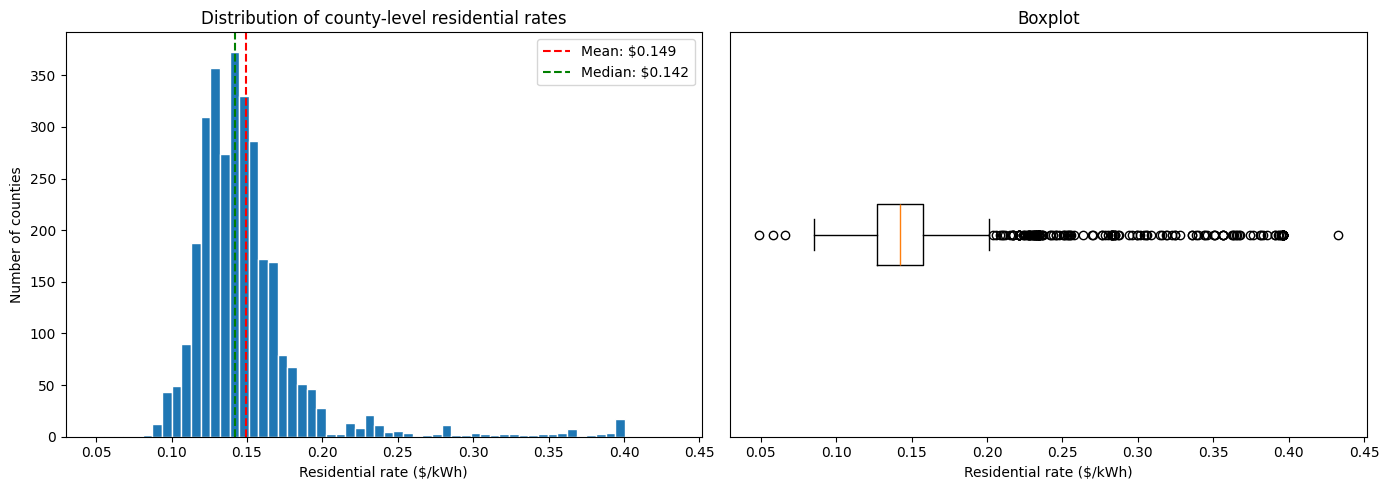

count    3089.000000
mean        0.149336
std         0.041533
min         0.048969
25%         0.127030
50%         0.142384
75%         0.157612
max         0.432490
Name: avg_res_rate, dtype: float64


In [16]:
# plot the distribution of utility rates

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df["avg_res_rate"], bins=60, edgecolor="white")
axes[0].axvline(df["avg_res_rate"].mean(), color="red", linestyle="--", label=f"Mean: ${df['avg_res_rate'].mean():.3f}")
axes[0].axvline(df["avg_res_rate"].median(), color="green", linestyle="--", label=f"Median: ${df['avg_res_rate'].median():.3f}")
axes[0].set_xlabel("Residential rate ($/kWh)")
axes[0].set_ylabel("Number of counties")
axes[0].set_title("Distribution of county-level residential rates")
axes[0].legend()

# boxplot
axes[1].boxplot(df["avg_res_rate"], vert=False)
axes[1].set_xlabel("Residential rate ($/kWh)")
axes[1].set_title("Boxplot")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print(df["avg_res_rate"].describe())

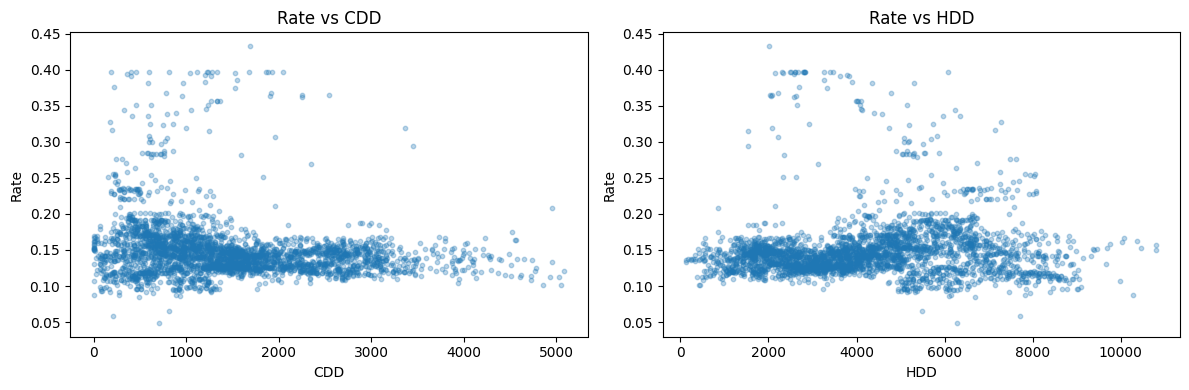

In [17]:
# plot utility rates vs. cooling & heating degree days
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["cdd_annual"], df["avg_res_rate"], alpha=0.3, s=10)
axes[0].set_xlabel("CDD")
axes[0].set_ylabel("Rate")
axes[0].set_title("Rate vs CDD")

axes[1].scatter(df["hdd_annual"], df["avg_res_rate"], alpha=0.3, s=10)
axes[1].set_xlabel("HDD")
axes[1].set_ylabel("Rate")
axes[1].set_title("Rate vs HDD")

plt.tight_layout()
plt.show()

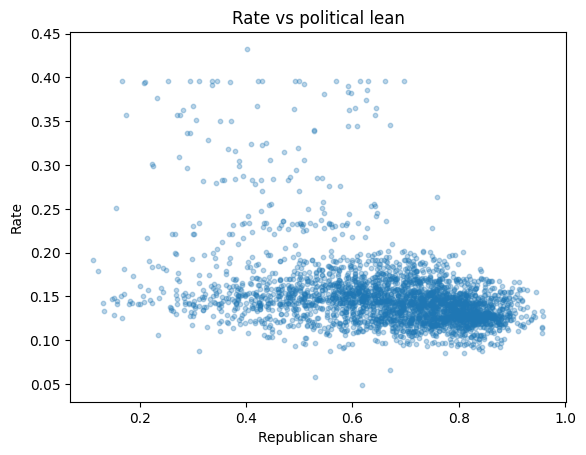

In [21]:
# plot rates vs. political leaning
plt.scatter(df["rep_share"], df["avg_res_rate"], alpha=0.3, s=10)
plt.xlabel("Republican share")
plt.ylabel("Rate")
plt.title("Rate vs political lean")
plt.show()

In [30]:
df['state'] = df['state'].str.title()

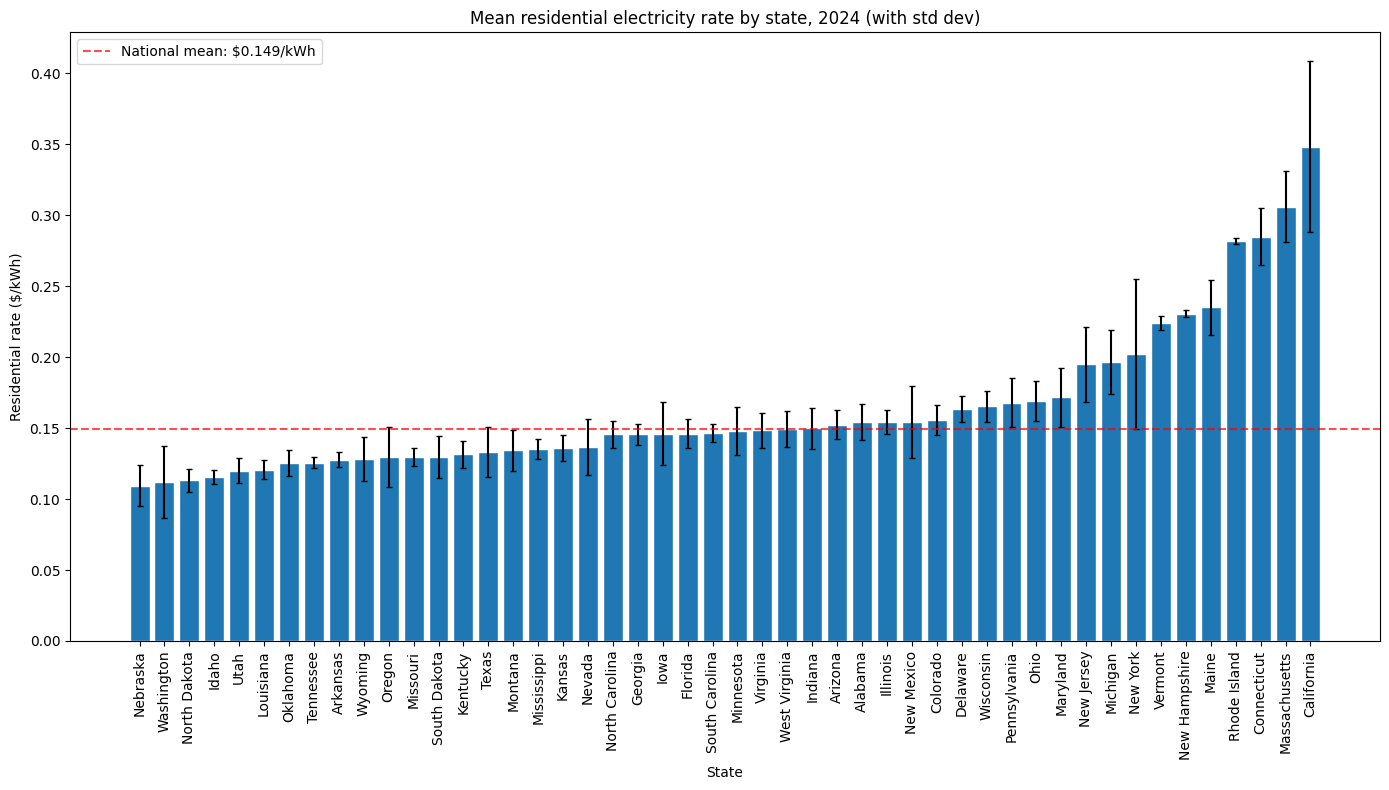

In [31]:
# get mean rate per state and sort
state_means = df.groupby("state")["avg_res_rate"].mean().sort_values()

# Also get standard deviation for error bars (optional but informative)
state_stds = df.groupby("state")["avg_res_rate"].std()

fig, ax = plt.subplots(figsize=(14, 8))
ax.bar(state_means.index, state_means.values,
       yerr=state_stds[state_means.index].values,
       capsize=2, edgecolor="white")

# Reference line for national mean
national_mean = df["avg_res_rate"].mean()
ax.axhline(national_mean, color="red", linestyle="--", alpha=0.7,
           label=f"National mean: ${national_mean:.3f}/kWh")

ax.set_xlabel("State")
ax.set_ylabel("Residential rate ($/kWh)")
ax.set_title("Mean residential electricity rate by state, 2024 (with std dev)")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

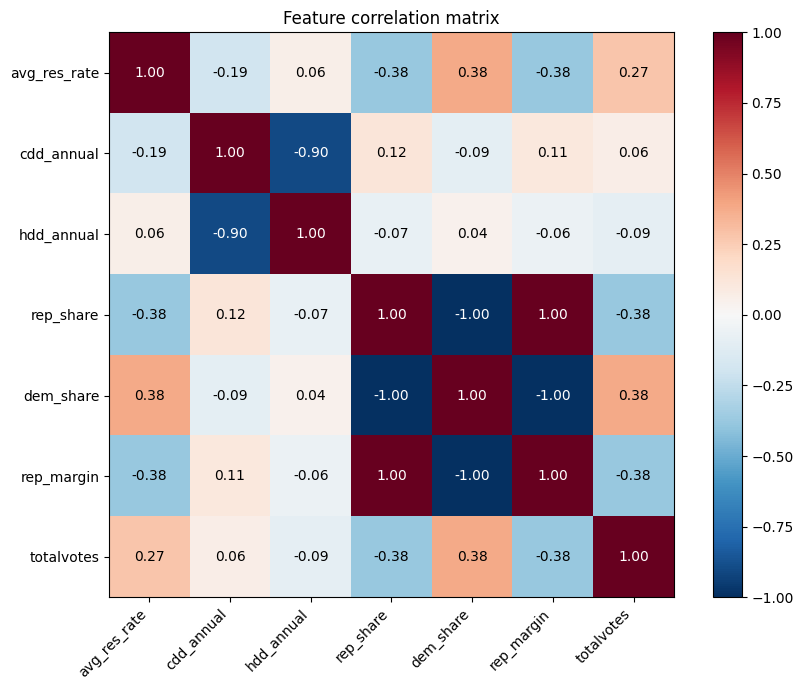

In [38]:
features = ["avg_res_rate", "cdd_annual", "hdd_annual", 
            "rep_share", "dem_share", "rep_margin", "totalvotes"]
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticklabels(features)

plt.colorbar(im, ax=ax)

for i in range(len(features)):
    for j in range(len(features)):
        value = corr.iloc[i, j]
        color = "white" if abs(value) > 0.5 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=color)

ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

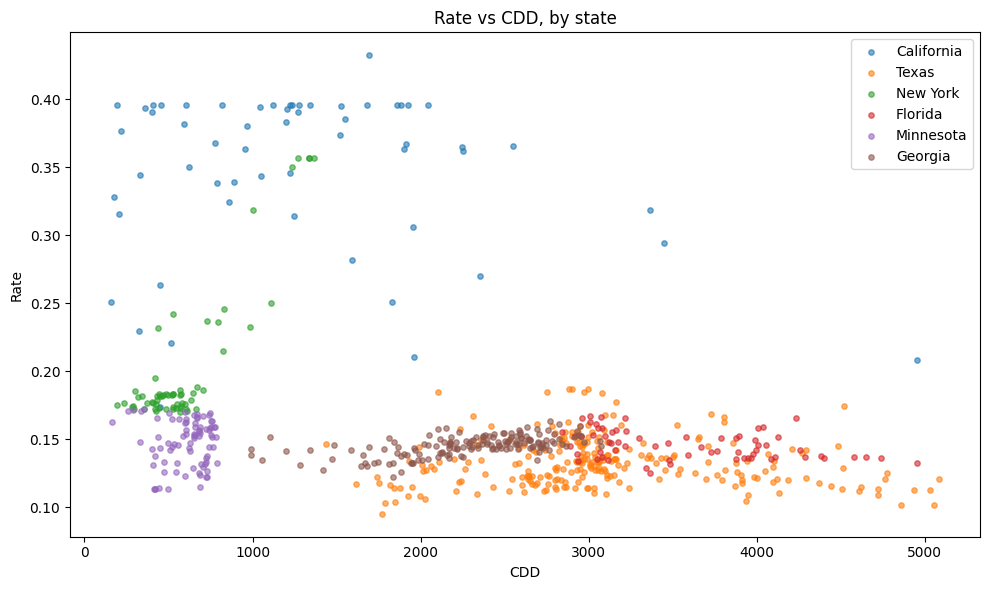

In [43]:
states_to_show = ["California", "Texas", "New York", "Florida", "Minnesota", "Georgia"]

fig, ax = plt.subplots(figsize=(10, 6))
for state in states_to_show:
    subset = df[df["state"] == state]
    ax.scatter(subset["cdd_annual"], subset["avg_res_rate"], 
               alpha=0.6, s=15, label=state)
ax.set_xlabel("CDD")
ax.set_ylabel("Rate")
ax.set_title("Rate vs CDD, by state")
ax.legend()
plt.tight_layout()
plt.show()

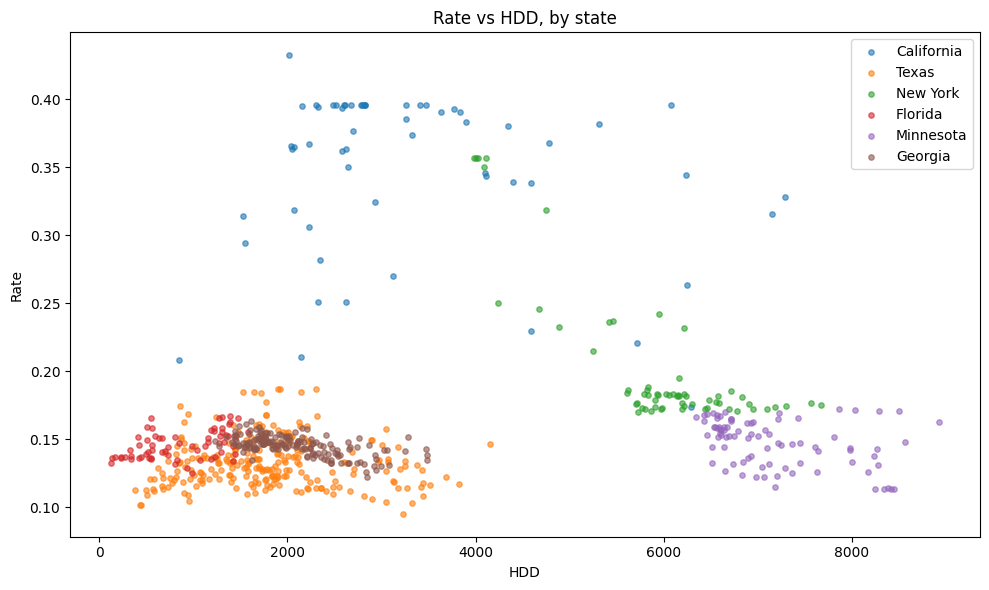

In [44]:
states_to_show = ["California", "Texas", "New York", "Florida", "Minnesota", "Georgia"]

fig, ax = plt.subplots(figsize=(10, 6))
for state in states_to_show:
    subset = df[df["state"] == state]
    ax.scatter(subset["hdd_annual"], subset["avg_res_rate"], 
               alpha=0.6, s=15, label=state)
ax.set_xlabel("HDD")
ax.set_ylabel("Rate")
ax.set_title("Rate vs HDD, by state")
ax.legend()
plt.tight_layout()
plt.show()